<a href="https://colab.research.google.com/github/sguimaraes-uchi/Notebooks/blob/main/Notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data and the State (DATA 21905/31905)
# Lab 1: Introduction to Census Data
## Friday, March 27

## Resources




* Python
  * [DataCamp's interactive Intro to Python tutorial](https://www.learnpython.org/)
  * [Python for Everybody (University of Michigan MOOC)](https://www.py4e.com/lessons)
  * [A short Python and NumPy tutorial (Stanford CS231)](http://cs231n.github.io/python-numpy-tutorial/)
  * [Official Python tutorial](https://docs.python.org/3/tutorial/index.html)
  * [Jake VanderPlas' _A Whirlwind Tour of Python_](https://github.com/jakevdp/WhirlwindTourOfPython/tree/master?tab=readme-ov-file) (particularly chapters 1–8)
  * [Cornell CS 1110 lecture videos (Fall 2020)](https://vod.video.cornell.edu/channel/CS+1110+Fall+2020/179890731)
* Pandas
    * [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
    * [Official pandas tutorials](https://pandas.pydata.org/docs/getting_started/index.html#intro-to-pandas)
    * [Data Manipulation with Pandas (chapter 3 of VanderPlas' *Python Data Science Handbook*)](https://jakevdp.github.io/PythonDataScienceHandbook/03.00-introduction-to-pandas.html)
    * [Introduction to GeoPandas](https://github.com/geopandas/geopandas/blob/main/doc/source/getting_started/introduction.ipynb) (Jupyter notebook)
    * [Comparison with R / R libraries](https://pandas.pydata.org/docs/getting_started/comparison/comparison_with_r.html) (a handy Rosetta stone if you've previously used R!)
    * [UC Berkeley Data 100 Early Lectures on Pandas and Visualization](https://ds100.org/su25/)
* Matplotlib
  * [Official Pyplot tutorial (short)](https://matplotlib.org/tutorials/introductory/pyplot.html)
  * [Visualization with Matplotlib (chapter 4 of VanderPlas' *Python Data Science Handbook*)](https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html)
  * [Gallery of Matplotlib examples](https://matplotlib.org/gallery/index.html)

   

## Exploring the US Census

In lab section, we'll explore the most famous and essential dataset published by the U.S. Census Bureau: the decennial enumeration of the U.S. population. This enumeration is [required by Article I of the U.S. Constitution](https://www.census.gov/programs-surveys/decennial-census/about/census-constitution.html). The challenges of processing Census data as the national population grew throughout the 19th century led to the development of [a tabulating machine](https://www.computerhistory.org/revolution/punched-cards/2/2) that was [first used for processing the 1890 U.S. Census](https://www.smithsonianmag.com/smithsonian-institution/herman-holleriths-tabulating-machine-2504989/). This machine read punch cards that encoded Census responses and generated summary statistics (such as the number of foreign-born children under 18 in a particular state, or the number of married women in a particular city). The company that developed this tabulating machine was later renamed to IBM.

The technical demands of analyzing U.S. Census data served as a catalyst in the early development of computing; in the 130 years or so since the dawn of this automated tabulation technology, Census data has become enormously more detailed and accessible. Here, we'll focus on a small slice of the 2010 and 2020 Decennial Census data that is published online via the [Census API](https://www.census.gov/data/developers/data-sets.html).

First we need to do some package setups. Run the following cells.

(It's not important that you understand the technical details of package setup, but feel free to read the comments below to get a basic idea.)

In [1]:
# You can ignore the contents of this cell for now. This is just to make sure we have the correct
# packages are installed for this lab.

# The `census` package is a wrapper around the US Census API, which allows us to easily query census
# data from Python easily. The `us` package provides a simple interface to get information about
# US states, such as their names and abbreviations.
!pip install -q census us

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 9.1 MB/s eta 0:00:00


In [2]:
# Here we set up our working environment by importing the necessary packages, classes, and
# functions.

# We import the `pandas` package, which is a powerful data manipulation library in Python.
# It provides data structures like DataFrames that make it easy to work with structured data
# (more on this later).
import pandas as pd


# From the `census` package, we import the `Census` class, which allows us to interact with the US
# Census API an ergonomic way. We will use this class to query census data in this lab.
from census import Census

# From the `us` package, we import the `states` module, which provides information about US states,
# such as their names, abbreviations, and FIPS codes. This will be useful for working with census
# data, which often uses FIPS (Federal Information Processing Standards) codes to identify states.
from us import states

## Fetching population data

Here, we'll retrieve population statistics by race from the Census API for all counties in Illinois. Census data releases are organized into tables; [Table P1](https://data.census.gov/table/DECENNIALPL2020.P1?g=040XX00US36) breaks down population by racial category.

The official column names used by the Census Bureau are frequently inscrutable (for instance, the `P1_004N` column corresponds to Black population), and so we provide a dictionary below that we will later use to make working with the data more intuitive. (Full column definitions are available in the [API documentation](https://api.census.gov/data/2020/dec/pl/variables.html).)

In [3]:
p1_population_columns = {
    "P1_003N": "White",         # White alone
    "P1_004N": "Black",         # Black or African American alone
    "P1_005N": "AMIN",          # American Indian and Alaska Native alone
    "P1_006N": "Asian",         # Asian alone
    "P1_007N": "NHPI",          # Native Hawaiian and Other Pacific Islander alone
    "P1_008N": "SomeOther",     # Some Other Race alone
    "P1_009N": "Multi",         # Two or more races
}

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


When fetching data from the Census API, we usually identify geographic regions (states, counties, etc.) by something called a [FIPS code](https://en.wikipedia.org/wiki/Federal_Information_Processing_Standard_state_code). For instance, the FIPS code for the state of Illinois is 17, which means that all the GEOIDs that refer to any geography in the state will start with 17. The `us` package exposes identifiers (FIPS codes, postal abbreviations) for the each U.S. state.

In [7]:
state = states.IL
print(state, state.abbr, state.fips)

Illinois IL 17


Now we will make use of the `Census` class we imported from the `census` module and specify:
* The dataset we wish to query (in this case the `pl` dataset which stands for "Public Law 94-171")
* The columns we want to fetch from the chosen dataset (the `NAME` column, and the 7 columns from Table P1 listed in `p1_population_columns` above).
* The regions we want column values for (all counties in Illinois).

>Coding notes:
> * The syntax `f"state:{state.fips}"` is a kind of [string formatting](https://docs.python.org/3/tutorial/inputoutput.html) in Python, which allows you to dynamically change the content of the string based on other defined variables (in this case, `state.fips`). You can alternatively replace this code with the hard-coded FIPS values (e.g., `"state:01"`).
> * The asterisk `*` allows you to select *all* values corresponding to either counties or states.

In [8]:
census = Census(
    key="",      # We do not have a Census API key, so we leave this blank.
    year=2020    # We specify that we would like to use the 2020 Census data.
)

census_column_list = ["NAME"] + list(p1_population_columns.keys())
# The `NAME` column contains the name of the geographic area (in this case, the county name),
# and the keys of our `p1_population_columns` dictionary correspond were the columns P1_003N to
# P1_009N in the census data, which contain the population counts for different racial groups.

county_populations = census.pl.get(
    census_column_list,
    geo={
        "for": "county:*",
        "in": f"state:{state.fips}",
    },
)

In [9]:
# # This is a backup cell just in case the census API and Google Coab do not cooperate with each other. Uncomment only if needed
# import json
# from urllib.request import urlopen

# url = "https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/backup_data/Notebook1_IL_census_county_p1_backup.json"

# with urlopen(url) as response:
#     county_populations = json.load(response)

**Note: there are several ways to modify the above code to get data for *multiple* counties and *multiple* states.**

For example, if you want to get data for multiple counties you can simply list them out by their FIPS codes.

```python
# This is not an executable cell
county_populations = census.pl.get(
    census_column_list,
    geo={
        "for": "county:001,002,003",
        "in": f"state:{state.fips}",
    }
)
```

Or, if you want to get data for all counties in *multiple states* you can list out the states by their FIPS codes.

```python
# This is not an executable cell
county_populations = census.pl.get(
    census_column_list,
    geo={
        "for": "county:*",
        "in": "state:01,02",
    }
)
```

The Census API returns a list of dictionaries; each contains column values for a county which we can print out.

In [10]:
# There are 102 counties in Illinois, so we should have 102 dictionaries in our
# `county_populations` list, but we are just going to print out the first 3 rows
# to check that our data looks correct.
county_populations[:3]

[{'NAME': 'Adams County, Illinois',
  'P1_003N': 58837.0,
  'P1_004N': 2501.0,
  'P1_005N': 104.0,
  'P1_006N': 513.0,
  'P1_007N': 39.0,
  'P1_008N': 526.0,
  'P1_009N': 3217.0,
  'state': '17',
  'county': '001'},
 {'NAME': 'Alexander County, Illinois',
  'P1_003N': 3311.0,
  'P1_004N': 1617.0,
  'P1_005N': 24.0,
  'P1_006N': 6.0,
  'P1_007N': 0.0,
  'P1_008N': 20.0,
  'P1_009N': 262.0,
  'state': '17',
  'county': '003'},
 {'NAME': 'Bond County, Illinois',
  'P1_003N': 14446.0,
  'P1_004N': 1077.0,
  'P1_005N': 52.0,
  'P1_006N': 105.0,
  'P1_007N': 11.0,
  'P1_008N': 360.0,
  'P1_009N': 674.0,
  'state': '17',
  'county': '005'}]

A list of dictionaries is not an ideal way of interacting with large datasets (unless you really, really like for loops), so we will now make use of the data manipulation library `pandas`.

For now, you can simply think of Pandas DataFrames as Python's version of spreadsheets. We can convert the raw census response to a Pandas `DataFrame` without any further manipulation.

In [11]:
# We create the dataframe `race_df` from the list of dictionaries `county_populations`.
# Each dictionary in the list represents a row in the dataframe, where the keys of the dictionary
# correspond to the column names and the values correspond to the data in those columns.
#
# We also make sure to store the dataframe in a variable called `race_df`, which so we can extract
# data from it later on in the lab.
race_df = pd.DataFrame(county_populations)

# We will have colab print out the dataframe `race_df` so we can see what it looks like.
race_df

,NAME,P1_003N,P1_004N,P1_005N,P1_006N,P1_007N,P1_008N,P1_009N,state,county
0,"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,17,001
1,"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,17,003
2,"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,17,005
3,"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0,17,007
4,"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,17,009
...,...,...,...,...,...,...,...,...,...,...
97,"Whiteside County, Illinois",47759.0,839.0,235.0,311.0,12.0,2134.0,4401.0,17,195
98,"Will County, Illinois",443562.0,80979.0,3974.0,42849.0,126.0,54431.0,70434.0,17,197
99,"Williamson County, Illinois",58897.0,2870.0,263.0,776.0,9.0,554.0,3784.0,17,199
100,"Winnebago County, Illinois",191124.0,39159.0,1632.0,8039.0,84.0,19059.0,26253.0,17,201


Okay, that's a lot of data! Generally, we don't want to view our entire Dataframe, so we can instead use the `head(<number_of_rows>)` and `tail(<number_of_rows>)` methods to take a peak at the first or last few rows of the DataFrame.

In [12]:
race_df.head(3)

,NAME,P1_003N,P1_004N,P1_005N,P1_006N,P1_007N,P1_008N,P1_009N,state,county
0,"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,17,001
1,"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,17,003
2,"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,17,005


## Data Querying and Postprocessing

### Modifying Dataframe Column Names and Indices

Currently, our `race_df` dataframe is a bit hard to work with (what does "P1_005N" mean again?), but we can make `race_df` more usable by applying our mapping from raw column names to human-readable, in this case race categories.

Below is an example of how to use the `rename` method to change the column titled "state" to "state_fips_code" and the column titled "county" to "county_fips".

In [13]:
race_df = race_df.rename(columns= {"state": "state_fips", "county": "county_fips"})
race_df

,NAME,P1_003N,P1_004N,P1_005N,P1_006N,P1_007N,P1_008N,P1_009N,state_fips,county_fips
0,"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,17,001
1,"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,17,003
2,"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,17,005
3,"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0,17,007
4,"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,17,009
...,...,...,...,...,...,...,...,...,...,...
97,"Whiteside County, Illinois",47759.0,839.0,235.0,311.0,12.0,2134.0,4401.0,17,195
98,"Will County, Illinois",443562.0,80979.0,3974.0,42849.0,126.0,54431.0,70434.0,17,197
99,"Williamson County, Illinois",58897.0,2870.0,263.0,776.0,9.0,554.0,3784.0,17,199
100,"Winnebago County, Illinois",191124.0,39159.0,1632.0,8039.0,84.0,19059.0,26253.0,17,201


#### TASK 1

Recall that we made a dictionary above called `p1_population_columns`. This maps census column names to names that can be more easily read and remembered. Use the `rename` method to introduce human-readable names into the `race_df` dataframe. It's possible to do this by renaming the columns individually like we did in the previous cell, but you can accomplish the same thing more simply by using the dictionary.


In [14]:
race_df= race_df.rename(columns={"P1_003N":"White","P1_004N":"Black", "P1_005N": "AMIN","P1_006N": "Asian", "P1_007N":"NHPI", "P1_008N": "SomeOther","P1_009N": "Multi"})

# but raise your hand and ask for help if you get stuck!
race_df # Leave this at the end to print out the dataframe so you can see if your code worked correctly.

,NAME,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,state_fips,county_fips
0,"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,17,001
1,"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,17,003
2,"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,17,005
3,"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0,17,007
4,"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,17,009
...,...,...,...,...,...,...,...,...,...,...
97,"Whiteside County, Illinois",47759.0,839.0,235.0,311.0,12.0,2134.0,4401.0,17,195
98,"Will County, Illinois",443562.0,80979.0,3974.0,42849.0,126.0,54431.0,70434.0,17,197
99,"Williamson County, Illinois",58897.0,2870.0,263.0,776.0,9.0,554.0,3784.0,17,199
100,"Winnebago County, Illinois",191124.0,39159.0,1632.0,8039.0,84.0,19059.0,26253.0,17,201


Since we are at the University of Chicago, we might be interested in looking at the data for Cook County.  Let's go deep enough in the alphabet to see it.

In [15]:
race_df.head(20)

,NAME,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,state_fips,county_fips
0,"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,17,001
1,"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,17,003
2,"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,17,005
3,"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0,17,007
4,"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,17,009
5,"Bureau County, Illinois",29358.0,275.0,147.0,300.0,21.0,1091.0,2052.0,17,011
6,"Calhoun County, Illinois",4227.0,7.0,10.0,7.0,0.0,20.0,166.0,17,013
7,"Carroll County, Illinois",14117.0,694.0,63.0,40.0,5.0,178.0,605.0,17,015
8,"Cass County, Illinois",9528.0,725.0,129.0,117.0,41.0,1594.0,908.0,17,017
9,"Champaign County, Illinois",129083.0,28675.0,783.0,24487.0,84.0,7756.0,14997.0,17,019


And we can grab the row containing just the data for Cook County using the `loc[<index>]` method for pandas dataframes. Below, we've put in row 0, which is Adams County.  CHANGE THIS to the correct row for Cook County.

In [16]:
# change the row to get Cook County
race_df.loc[15]

,15
NAME,"Cook County, Illinois"
White,2345983.0
Black,1205824.0
AMIN,56894.0
Asian,413271.0
NHPI,1864.0
SomeOther,705153.0
Multi,546552.0
state_fips,17
county_fips,031


Locating data by its integer index can still be cumbersome, so it is often convenient to _reindex_ the dataframe to use a more intuitive choice of unique identifier. Basically the choice of index column will specify how you want to refer to rows, so choosing `NAME` means we'll refer to counties by their name instead of number.

In [17]:
# Change counties to be the index.
race_df = race_df.set_index("NAME")
race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,state_fips,county_fips
NAME,,,,,,,,,
"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,17,001
"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,17,003
"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,17,005
"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0,17,007
"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,17,009
...,...,...,...,...,...,...,...,...,...
"Whiteside County, Illinois",47759.0,839.0,235.0,311.0,12.0,2134.0,4401.0,17,195
"Will County, Illinois",443562.0,80979.0,3974.0,42849.0,126.0,54431.0,70434.0,17,197
"Williamson County, Illinois",58897.0,2870.0,263.0,776.0,9.0,554.0,3784.0,17,199


Notice that the leftmost column has now changed to "NAME."

In [18]:
# Remember that the `loc` method accesses the INDEX of the dataframe
race_df.loc["Cook County, Illinois"]

,"Cook County, Illinois"
White,2345983.0
Black,1205824.0
AMIN,56894.0
Asian,413271.0
NHPI,1864.0
SomeOther,705153.0
Multi,546552.0
state_fips,17
county_fips,031


Note that if we now try to access the data for Cook County using its integer index, we will get a `KeyError`

In [ ]:
race_df.loc[15]

Let's do a bit of cleanup. Since we are looking at racial composition data, we probably don't need to hold onto state or county fips codes in our dataframe any more, so let's use the `drop` method to remove them.

In [19]:
race_df = race_df.drop(columns=["state_fips", "county_fips"])
race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi
NAME,,,,,,,
"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0
"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0
"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0
"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0
"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0
...,...,...,...,...,...,...,...
"Whiteside County, Illinois",47759.0,839.0,235.0,311.0,12.0,2134.0,4401.0
"Will County, Illinois",443562.0,80979.0,3974.0,42849.0,126.0,54431.0,70434.0
"Williamson County, Illinois",58897.0,2870.0,263.0,776.0,9.0,554.0,3784.0


### Data Manipulation

Pandas dataframes come equipped with many "convenience functions" that allow us to manipulate and process data. For example, we can sum the values in the White column to obtain the total number of people that identify as White in the state.

In [20]:
# Here, the syntax `race_df["White"]` accesses the "White" column of the dataframe, which contains
# the population count of White people in each county. The `sum()` method then adds up all the
# values in that column to give us the total population of White people across all counties in Illinois.
race_df["White"].sum()

np.float64(7868227.0)

Or we can sum the values in every column at once to compute population totals by racial category for the state.

Pandas dataframes use the convention that `axis=0` refers to an operation along the rows (i.e., by column), and `axis=1` means along the columns (i.e., by row).

In [21]:
race_df.sum(axis=0)  # axis = 0 means sum across columns

,0
White,7868227.0
Black,1808271.0
AMIN,96498.0
Asian,754878.0
NHPI,4501.0
SomeOther,1135149.0
Multi,1144984.0


Similarly, we can sum the values in each row to compute population totals (across all racial categories) for each county.

In [22]:
race_df.sum(axis=1)  # axis = 1 means sum across rows

,0
NAME,
"Adams County, Illinois",65737.0
"Alexander County, Illinois",5240.0
"Bond County, Illinois",16725.0
"Boone County, Illinois",53448.0
"Brown County, Illinois",6244.0
...,...
"Whiteside County, Illinois",55691.0
"Will County, Illinois",696355.0
"Williamson County, Illinois",67153.0


In order to answer questions like "which county in Illinois has the largest _share_ of Black population?" we will convert absolute population counts to percentages. To do this, it's convenient to first compute a `total` column and add that to the dataframe.

In [23]:
# Here the syntax race_df["total"] creates a new column in the dataframe called "total", and assigns
# to it the result of summing all the values in each row of the dataframe (i.e. the total
# population of each county across all racial groups).
race_df["total"] = race_df.sum(axis=1)

In [24]:
race_df.head(5)

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total
NAME,,,,,,,,
"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,65737.0
"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,5240.0
"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,16725.0
"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0,53448.0
"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,6244.0


To create the percentage column for a particular racial category, we can then use _vector arithmetic_ to divide a racial column by the total population:

In [25]:
# Here, we create a new column called "White_pct" that contains the percentage of the population that is
# white in each county. We calculate this by dividing the total population of each county (which we
# just calculated in the "total" column) by the population of White people in each county
# (which is in the "White" column), and then multiplying by 100 to get a percentage.
race_df["White_pct"] = 100 * (race_df["White"] / race_df["total"])
race_df.head(5)

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct
NAME,,,,,,,,,
"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,65737.0,89.503628
"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,5240.0,63.187023
"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,16725.0,86.373692
"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0,53448.0,72.530310
"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,6244.0,76.537476


And if we want to spot-check our work, we can extract the columns that we used in our computations from `race_df` and store those in a new dataframe.

In [26]:
# Note that the syntax `race_df[["White", "total", "White_pct"]]` creates a new dataframe that only
# contains the "White", "total", and "White_pct" columns from the original dataframe `race_df`.
computation_check_df = race_df[["White", "total", "White_pct"]]
computation_check_df.head(5)

,White,total,White_pct
NAME,,,
"Adams County, Illinois",58837.0,65737.0,89.503628
"Alexander County, Illinois",3311.0,5240.0,63.187023
"Bond County, Illinois",14446.0,16725.0,86.373692
"Boone County, Illinois",38766.0,53448.0,72.530310
"Brown County, Illinois",4779.0,6244.0,76.537476


#### TASK 2

Add a column called "Black_pct" to `race_df` that records the percent of the population that identifies as Black alone.

In [27]:
race_df["Black_pct"] = 100 * (race_df["Black"] / race_df["total"])
race_df[["Black", "total", "Black_pct"]] # This just prints out the dataframe so you can see if your code worked correctly.

,Black,total,Black_pct
NAME,,,
"Adams County, Illinois",2501.0,65737.0,3.804555
"Alexander County, Illinois",1617.0,5240.0,30.858779
"Bond County, Illinois",1077.0,16725.0,6.439462
"Boone County, Illinois",1245.0,53448.0,2.329367
"Brown County, Illinois",1054.0,6244.0,16.880205
...,...,...,...
"Whiteside County, Illinois",839.0,55691.0,1.506527
"Will County, Illinois",80979.0,696355.0,11.628982
"Williamson County, Illinois",2870.0,67153.0,4.273822


We would like to have a column containing the racial population percentage for each racial category, which we could do by hand, but is easier to do with a `for` loop.

In [28]:
# Here we are just extracting the population column names from the `p1_population_columns`
# dictionary and storing them in a list called `categories`.
categories = list(p1_population_columns.values())
categories

['White', 'Black', 'AMIN', 'Asian', 'NHPI', 'SomeOther', 'Multi']

In [29]:
# Now we loop through the population categories in our list and add a column to our dataframe for each.
for col in categories:
    race_df[f"{col}_pct"] = 100 * race_df[col] / race_df["total"]

race_df.head(3)

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
NAME,,,,,,,,,,,,,,,
"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,65737.0,89.503628,3.804555,0.158206,0.780382,0.059327,0.800158,4.893743
"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,5240.0,63.187023,30.858779,0.458015,0.114504,0.000000,0.381679,5.000000
"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,16725.0,86.373692,6.439462,0.310912,0.627803,0.065770,2.152466,4.029895


Armed with these percentages, we can now answer demographic questions cast in terms of population shares. For instance, sorting `race_df` by `White_pct` shows that Jasper County contains the largest White population share in the state, while Cook County contains the smallest White share.

In [30]:
# Note that the `sort_values` method sorts values from smallest to largest by default, so the
# county with the county with the highest percentage of white people will be at the bottom.
race_df = race_df.sort_values(by=["White_pct"])
race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
NAME,,,,,,,,,,,,,,,
"Cook County, Illinois",2345983.0,1205824.0,56894.0,413271.0,1864.0,705153.0,546552.0,5275541.0,44.469051,22.856879,1.078449,7.833718,0.035333,13.366459,10.360113
"St. Clair County, Illinois",153376.0,76564.0,881.0,3711.0,188.0,5288.0,17392.0,257400.0,59.586636,29.745144,0.342269,1.441725,0.073038,2.054390,6.756799
"Kane County, Illinois",309835.0,27538.0,6997.0,21634.0,217.0,83560.0,66741.0,516522.0,59.984860,5.331428,1.354637,4.188399,0.042012,16.177433,12.921231
"Lake County, Illinois",435395.0,49035.0,7112.0,59390.0,440.0,86580.0,76390.0,714342.0,60.950497,6.864359,0.995602,8.313945,0.061595,12.120245,10.693757
"Champaign County, Illinois",129083.0,28675.0,783.0,24487.0,84.0,7756.0,14997.0,205865.0,62.702742,13.929031,0.380346,11.894688,0.040803,3.767518,7.284871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Greene County, Illinois",11492.0,23.0,13.0,22.0,3.0,36.0,396.0,11985.0,95.886525,0.191907,0.108469,0.183563,0.025031,0.300375,3.304130
"Shelby County, Illinois",20197.0,65.0,39.0,83.0,1.0,95.0,510.0,20990.0,96.222010,0.309671,0.185803,0.395426,0.004764,0.452596,2.429728
"Scott County, Illinois",4765.0,5.0,3.0,11.0,1.0,13.0,151.0,4949.0,96.282077,0.101031,0.060618,0.222267,0.020206,0.262679,3.051121


#### TASK 3

The `sort_values` method has a keyword parameter called "ascending" that determines if the values in the dataframe are sorted from smallest to largest or vice versa (see [the documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html]) for more info).


Modify the following code cell to rank counties in Illinois by `Black_pct`, showing counties with the largest percentage at the top.

In [31]:
# Modify this!
race_df = race_df.sort_values(by=["Black_pct"], ascending=True)
race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
NAME,,,,,,,,,,,,,,,
"Scott County, Illinois",4765.0,5.0,3.0,11.0,1.0,13.0,151.0,4949.0,96.282077,0.101031,0.060618,0.222267,0.020206,0.262679,3.051121
"Calhoun County, Illinois",4227.0,7.0,10.0,7.0,0.0,20.0,166.0,4437.0,95.267072,0.157764,0.225378,0.157764,0.000000,0.450755,3.741267
"Greene County, Illinois",11492.0,23.0,13.0,22.0,3.0,36.0,396.0,11985.0,95.886525,0.191907,0.108469,0.183563,0.025031,0.300375,3.304130
"Jasper County, Illinois",8968.0,23.0,22.0,17.0,4.0,38.0,215.0,9287.0,96.565091,0.247658,0.236890,0.183052,0.043071,0.409174,2.315064
"Cumberland County, Illinois",9984.0,28.0,22.0,23.0,5.0,30.0,358.0,10450.0,95.540670,0.267943,0.210526,0.220096,0.047847,0.287081,3.425837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Peoria County, Illinois",122629.0,34015.0,550.0,7779.0,66.0,5035.0,11756.0,181830.0,67.441566,18.707034,0.302480,4.278172,0.036298,2.769070,6.465380
"Cook County, Illinois",2345983.0,1205824.0,56894.0,413271.0,1864.0,705153.0,546552.0,5275541.0,44.469051,22.856879,1.078449,7.833718,0.035333,13.366459,10.360113
"Pulaski County, Illinois",3261.0,1466.0,41.0,13.0,0.0,162.0,250.0,5193.0,62.796072,28.230310,0.789524,0.250337,0.000000,3.119584,4.814173


### Filtering

Next, we will _filter_ our dataframe. Suppose, for example, we want to know which counties are more than 15% Black. One way to do this is to construct a "boolean mask" for our dataframe -- that is, a series of True and False values that we'll use to filter.

In [32]:
# This will print out a T/F series that indicates whether the population in a given county is
# more than 15% Black.
race_df["Black_pct"] > 15

,Black_pct
NAME,
"Scott County, Illinois",False
"Calhoun County, Illinois",False
"Greene County, Illinois",False
"Jasper County, Illinois",False
"Cumberland County, Illinois",False
...,...
"Peoria County, Illinois",True
"Cook County, Illinois",True
"Pulaski County, Illinois",True


To actually get the rows in the dataframe that satisfy our condition, we can incorporate this mask into the following syntax:

In [33]:
# This syntax says "access those locations (indices) in the dataframe where the condition
# `race_df["Black_pct"] > 15` is True".
race_df.loc[race_df["Black_pct"] > 15]

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
NAME,,,,,,,,,,,,,,,
"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,6244.0,76.537476,16.880205,0.176169,0.192184,0.000000,3.363229,2.850737
"Macon County, Illinois",75809.0,19047.0,237.0,1515.0,36.0,1238.0,6116.0,103998.0,72.894671,18.314775,0.227889,1.456759,0.034616,1.190408,5.880882
"Peoria County, Illinois",122629.0,34015.0,550.0,7779.0,66.0,5035.0,11756.0,181830.0,67.441566,18.707034,0.302480,4.278172,0.036298,2.769070,6.465380
"Cook County, Illinois",2345983.0,1205824.0,56894.0,413271.0,1864.0,705153.0,546552.0,5275541.0,44.469051,22.856879,1.078449,7.833718,0.035333,13.366459,10.360113
"Pulaski County, Illinois",3261.0,1466.0,41.0,13.0,0.0,162.0,250.0,5193.0,62.796072,28.230310,0.789524,0.250337,0.000000,3.119584,4.814173
"St. Clair County, Illinois",153376.0,76564.0,881.0,3711.0,188.0,5288.0,17392.0,257400.0,59.586636,29.745144,0.342269,1.441725,0.073038,2.054390,6.756799
"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,5240.0,63.187023,30.858779,0.458015,0.114504,0.000000,0.381679,5.000000


And we can make more complicated filters too.

In [34]:
# We can also combine multiple conditions using the `&` operator, which stands for "and" (i.e., an intersection). This will give us
# the counties where the population is more than 15% Black AND more than 70% White.
race_df.loc[(race_df["Black_pct"] > 15) & (race_df["White_pct"] > 70)]

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
NAME,,,,,,,,,,,,,,,
"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,6244.0,76.537476,16.880205,0.176169,0.192184,0.000000,3.363229,2.850737
"Macon County, Illinois",75809.0,19047.0,237.0,1515.0,36.0,1238.0,6116.0,103998.0,72.894671,18.314775,0.227889,1.456759,0.034616,1.190408,5.880882


In [35]:
# Likewise, the `|` operator, which stands for "or". This will give us
# the counties where the population is more than 20% Black OR more than 5% Asian.
race_df.loc[(race_df["Black_pct"] > 20) | (race_df["Asian_pct"] > 5)]

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
NAME,,,,,,,,,,,,,,,
"DuPage County, Illinois",616830.0,45516.0,5154.0,119672.0,315.0,62732.0,82658.0,932877.0,66.121257,4.879100,0.552484,12.828272,0.033767,6.724574,8.860546
"Lake County, Illinois",435395.0,49035.0,7112.0,59390.0,440.0,86580.0,76390.0,714342.0,60.950497,6.864359,0.995602,8.313945,0.061595,12.120245,10.693757
"Will County, Illinois",443562.0,80979.0,3974.0,42849.0,126.0,54431.0,70434.0,696355.0,63.697683,11.628982,0.570686,6.153327,0.018094,7.816559,10.114669
"Champaign County, Illinois",129083.0,28675.0,783.0,24487.0,84.0,7756.0,14997.0,205865.0,62.702742,13.929031,0.380346,11.894688,0.040803,3.767518,7.284871
"Cook County, Illinois",2345983.0,1205824.0,56894.0,413271.0,1864.0,705153.0,546552.0,5275541.0,44.469051,22.856879,1.078449,7.833718,0.035333,13.366459,10.360113
"Pulaski County, Illinois",3261.0,1466.0,41.0,13.0,0.0,162.0,250.0,5193.0,62.796072,28.230310,0.789524,0.250337,0.000000,3.119584,4.814173
"St. Clair County, Illinois",153376.0,76564.0,881.0,3711.0,188.0,5288.0,17392.0,257400.0,59.586636,29.745144,0.342269,1.441725,0.073038,2.054390,6.756799
"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,5240.0,63.187023,30.858779,0.458015,0.114504,0.000000,0.381679,5.000000


In [36]:
# And vector operations still work as expected.
# This will give us the counties where the total Black and Asian population is more than 25% of the total population.
race_df.loc[(race_df["Black_pct"] + race_df["Asian_pct"]) > 25]

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
NAME,,,,,,,,,,,,,,,
"Champaign County, Illinois",129083.0,28675.0,783.0,24487.0,84.0,7756.0,14997.0,205865.0,62.702742,13.929031,0.380346,11.894688,0.040803,3.767518,7.284871
"Cook County, Illinois",2345983.0,1205824.0,56894.0,413271.0,1864.0,705153.0,546552.0,5275541.0,44.469051,22.856879,1.078449,7.833718,0.035333,13.366459,10.360113
"Pulaski County, Illinois",3261.0,1466.0,41.0,13.0,0.0,162.0,250.0,5193.0,62.796072,28.230310,0.789524,0.250337,0.000000,3.119584,4.814173
"St. Clair County, Illinois",153376.0,76564.0,881.0,3711.0,188.0,5288.0,17392.0,257400.0,59.586636,29.745144,0.342269,1.441725,0.073038,2.054390,6.756799
"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,5240.0,63.187023,30.858779,0.458015,0.114504,0.000000,0.381679,5.000000


#### TASK 4

Use a boolean mask to find all of the counties where both `SomeOther_pct` and `Multi_pct` are larger than 10. Hint: there should be 4 of them!

In [38]:
# Modify the line below
filtered_df = race_df.loc[(race_df["SomeOther_pct"] > 10) & (race_df["Multi_pct"] > 10)]
filtered_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
NAME,,,,,,,,,,,,,,,
"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0,53448.0,72.530310,2.329367,0.931747,1.232974,0.044903,11.555156,11.375543
"Kane County, Illinois",309835.0,27538.0,6997.0,21634.0,217.0,83560.0,66741.0,516522.0,59.984860,5.331428,1.354637,4.188399,0.042012,16.177433,12.921231
"Lake County, Illinois",435395.0,49035.0,7112.0,59390.0,440.0,86580.0,76390.0,714342.0,60.950497,6.864359,0.995602,8.313945,0.061595,12.120245,10.693757
"Cook County, Illinois",2345983.0,1205824.0,56894.0,413271.0,1864.0,705153.0,546552.0,5275541.0,44.469051,22.856879,1.078449,7.833718,0.035333,13.366459,10.360113


## Plotting with Matplotlib

Matplotlib is another essential package in the Python data science ecosystem. Matplotlib can generate almost any 2D plot imaginable (see the [examples gallery](https://matplotlib.org/stable/gallery/index.html)), and it's tightly integrated with Pandas and GeoPandas.


### Importing
We conventionally load Matplotlib as `plt` for short. The examples here also use [NumPy](https://numpy.org/doc/stable/reference/) (imported as `np` for short) to generate large arrays of random numbers.



In [39]:
import matplotlib.pyplot as plt
import numpy as np


# The next line of code tells Google Colab to render all plots and charts as
# SVG (Scalable Vector Graphics) instead of #the default PNG which will make
# our plots look nicer
%config InlineBackend.figure_formats = ["svg"]

### Line Plots

When working in a notebook, it's often preferable to configure Matplotlib to emit [vector images](https://en.wikipedia.org/wiki/Vector_graphics). We're going to plot a simple line next, and save it as both a PNG and an SVG.  Navigate to the file button on the left hand tool menu to open up both kinds of plot, and zoom way in to see the difference: the PNG format is pixellated, while the SVG format is infinitely zoomable.

We'll set up a first plot.  As you will see, `ax.plot` defaults to a line plot.

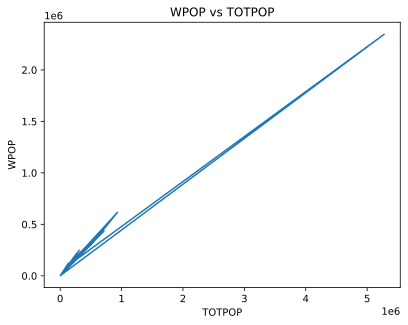

In [40]:
# this plots TOTPOP on the x-axis and WPOP on the y-axis

White_pop = race_df["White"]
total_pop = race_df["total"]

fig, ax = plt.subplots()
ax.plot(total_pop,White_pop)
ax.set_xlabel("TOTPOP")
ax.set_ylabel("WPOP")
ax.set_title("WPOP vs TOTPOP")
plt.savefig("line.png") #this is how you save a plot
plt.savefig("line.svg")
plt.show()

It's hard to understand this visually.  Let's repeat the code block but adjust the axes to have the same range and make sure it's square.

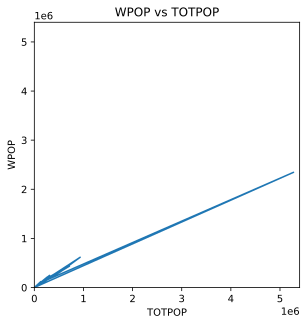

In [41]:
# this plots TOTPOP on the x-axis and WPOP on the y-axis

White_pop = race_df["White"]
total_pop = race_df["total"]

fig, ax = plt.subplots()
ax.plot(total_pop,White_pop)
ax.set_xlabel("TOTPOP")
ax.set_ylabel("WPOP")
ax.set_title("WPOP vs TOTPOP")
# Cook county has 5.2something million people, so let's set the range a little larger.
ax.set_xlim(0,5.4e6)
ax.set_ylim(0,5.4e6)
# let's also insist on a square, i.e., an equal aspect ratio
ax.set_aspect("equal")
plt.savefig("line.png") #this is how you save a plot
plt.savefig("line.svg")
plt.show()

But honestly, this kind of data isn't really best understood with a line plot because it's not sequential.  One of the skills we want to teach is choosing an appropriate way to present your data.  Let's switch to a scatter....

### Scatter Plots


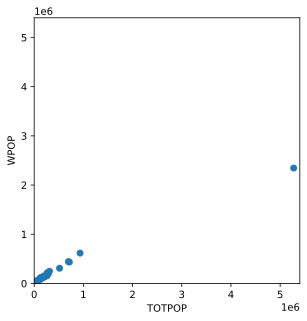

In [42]:
fig, ax = plt.subplots()
ax.scatter(total_pop, White_pop)  # scatter instead of plot here
ax.set_xlabel("TOTPOP")
ax.set_ylabel("WPOP")
# Cook county has 5.2something million people, so let's set the range a little larger.
ax.set_xlim(0,5.4e6)
ax.set_ylim(0,5.4e6)
# let's also insist on a square, i.e., an equal aspect ratio
ax.set_aspect("equal")
plt.show()

#### TASK 5

Matplotlib's `scatter` function comes with a parameter `s` (short for "size") which controls the size of the dots. Modify the code below so that
- the scatter plot has dots of size 100
- the points of the scatter plot are colored "red".

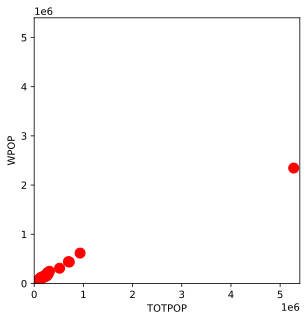

In [43]:
# Modify this code!

fig, ax = plt.subplots()
ax.scatter(total_pop, White_pop, s=100, color="red")  # scatter instead of plot here
ax.set_xlabel("TOTPOP")
ax.set_ylabel("WPOP")
# Cook county has 5.2something million people, so let's set the range a little larger.
# 5.4e6 is scientific notation for 5,400,000 = 5.4 * 10^6
ax.set_xlim(0,5.4e6)
ax.set_ylim(0,5.4e6)
# let's also insist on a square, i.e., an equal aspect ratio
ax.set_aspect("equal")
plt.show()

### Histograms

Let's make a histogram showing the distribution of AMIN share across counties.  First we'll look at the dataframe to get a sense of the numbers.

In [44]:
race_df["AMIN_pct"].sort_values(ascending=True)

,AMIN_pct
NAME,
"Hardin County, Illinois",0.000000
"Scott County, Illinois",0.060618
"Gallatin County, Illinois",0.101092
"Jersey County, Illinois",0.106917
"Greene County, Illinois",0.108469
...,...
"Boone County, Illinois",0.931747
"Cass County, Illinois",0.989112
"Lake County, Illinois",0.995602


First stab at a histogram.

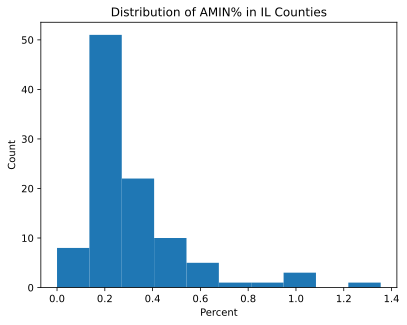

In [45]:
# in this histogram, we'll use automatic binning
fig, ax = plt.subplots()
ax.hist(race_df["AMIN_pct"] , bins=10)
ax.set_title("Distribution of AMIN% in IL Counties")
ax.set_xlabel("Percent")
ax.set_ylabel("Count")
plt.show()

MAJOR ISSUE: automatic bins in matplotlib are not intuitive.  When you need precise control of where the bins break and where they are centered, you need to be careful about it!

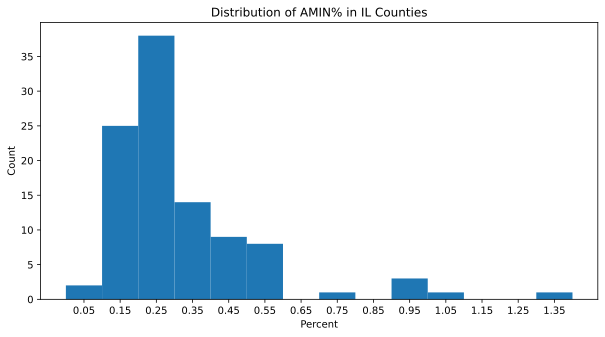

In [46]:
# in this histogram, we'll use hand-adjusted binning
# we'll also set the figure size to be wider than it is tall, so the axis labels are legible
fig, ax = plt.subplots(figsize=(10,5))
# since the data goes from 0 to 1.35, we'll have the bins go from 0 to 1.5 in increments of 0.1
ax.hist(race_df["AMIN_pct"], bins=np.arange(0,1.5,0.1))
# now we'll place tick marks in the centers
ax.set_xticks(np.arange(0.05,1.45,0.1))
ax.set_title("Distribution of AMIN% in IL Counties")
ax.set_xlabel("Percent")
ax.set_ylabel("Count")
plt.show()

#### Try this yourself!  

Go through the whole histogram workflow for Black population.  (This will be your upload at the end of lab.)

In [47]:
race_df["Black_pct"].sort_values(ascending=True)

,Black_pct
NAME,
"Scott County, Illinois",0.101031
"Calhoun County, Illinois",0.157764
"Greene County, Illinois",0.191907
"Jasper County, Illinois",0.247658
"Cumberland County, Illinois",0.267943
...,...
"Peoria County, Illinois",18.707034
"Cook County, Illinois",22.856879
"Pulaski County, Illinois",28.230310


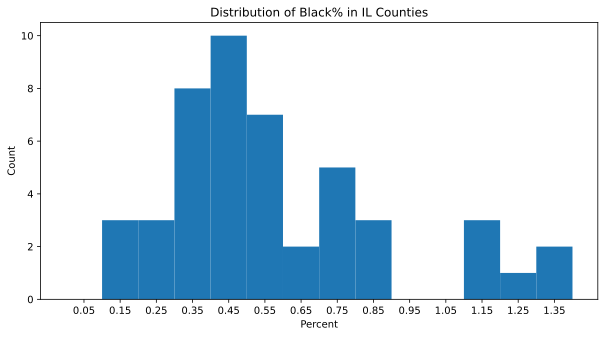

<Figure size 640x480 with 0 Axes>

In [49]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(race_df["Black_pct"], bins=np.arange(0,1.5,0.1))
ax.set_xticks(np.arange(0.05,1.45,0.1))
ax.set_title("Distribution of Black% in IL Counties")
ax.set_xlabel("Percent")
ax.set_ylabel("Count")
plt.show()
plt.savefig("Lab1plot.png")

### Visualizing demographics with a pie chart

We can visualize the demographic breakdown of a particular county with the [Pandas pie chart function](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.pie.html), which wraps around matplotlib's pie chart function.

In [ ]:
pie_df = race_df[list(p1_population_columns.values())] # selects only population counts for all races
county = "Cook County, Illinois"
ax = pie_df.loc[county].plot.pie(figsize=(10, 10), legend=False)
ax.set_title(f"Population of {county} by race")
ax.set_ylabel("")
plt.show()

We can visualize the demographic breakdown of the whole state in a similar fashion: first, we compute total population by race for the entire state (as illustrated in the section above), and then we plot the resulting Pandas `Series`. This pie chart improves on the county-level pie chart above by showing percentages for each racial category (rounded to the nearest 0.1%).

In [ ]:
ax = pie_df.sum(axis=0).plot.pie(figsize=(10, 10), autopct="%1.1f%%")
ax.set_ylabel("")
ax.set_title(f"Population of {state} by race")
plt.show()

What if we want to see those next to each other?

In [ ]:
# subplots 1,2 means to make a grid with 1 row and 2 columns
fig,ax=plt.subplots(1,2,figsize=(12,8))
pie_df.sum(axis=0).plot.pie(legend=False, ax=ax[0])
ax[0].set_title(f"Population of {state} by race")
ax[0].set_ylabel("")
pie_df.loc[county].plot.pie(legend=False, ax=ax[1])
ax[1].set_title(f"Population of {county} by race")
ax[1].set_ylabel("")
plt.show()

## LAB TURN-IN PLOT

Plot the distribution of BPOP% in Illinois counties, adapting the workflow we used in the histogram section above for AMIN%.

## Adding a dimension: Hispanic or Latino origin

The U.S. Census Bureau does not consider "Hispanic or Latino" a racial category; rather, it is the only "ethnicity." ([This is supposed to change with the 2030 Census](https://www.npr.org/2023/01/26/1151608403/mena-race-categories-us-census-middle-eastern-latino-hispanic)). Hispanic or Latino origin and racial identification were therefore considered in separate questions on the 2020 Census questionnaire.

[Table P2](https://data.census.gov/table/DECENNIALPL2020.P2?g=040XX00US36) contains population totals broken down by both race _and_ Hispanic/Latino origin. Let's retrieve county-level statistics from this table. (As with Table P1, column definitions are available in the [API documentation](https://api.census.gov/data/2020/dec/pl/variables.html).) When we rename columns derived from Table P2, **we'll use the prefix `nh_` for columns containing non-Hispanic population and the prefix `h_` for columns containing Hispanic population.**

In [ ]:
p2_non_hispanic_population_columns = {
    "P2_005N": "nh_White",         # White alone
    "P2_006N": "nh_Black",         # Black or African American alone
    "P2_007N": "nh_AMIN",          # American Indian and Alaska Native alone
    "P2_008N": "nh_Asian",         # Asian alone
    "P2_009N": "nh_NHPI",          # Native Hawaiian and Other Pacific Islander alone
    "P2_010N": "nh_SomeOther",     # Some Other Race alone
    "P2_011N": "nh_Multi",         # Two or more races
}

## TASK 6

Using the P1 fetch cell above as a model, fetch the P2 data for all counties in Illinois. Store the result in a variable called `county_non_hispanic_populations`.

In [ ]:
# YOUR CODE GOES HERE


# and then we'll see how it came out
race_ethnicity_df = pd.DataFrame(county_non_hispanic_populations)

# This is another backup just in case you are still having trouble with the Census API.
# race_ethnicity_df = pd.read_json("https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/backup_data/Notebook1_nh_IL_census_county_p2_backup.json")

race_ethnicity_df.head(5)

We can apply the same postprocessing steps we applied to Table P1 to clean up the column names.

In [ ]:
race_ethnicity_df = (
    race_ethnicity_df.rename(
        columns={"NAME": "name", **p2_non_hispanic_population_columns}
        # The `**` here "unpacks" p2_non_hispanic_population_columns into the larger
        # dictionary, so this is equivalent to writing out all its key-value pairs
        # individually alongside "NAME": "name".
    )
    .drop(columns=["state", "county"])
    .set_index("name")
)

In [ ]:
race_ethnicity_df

Table P2 only includes _non_-Hispanic population by race, but we can easily derive Hispanic population by race by incorporating totals from Table P1.

In [ ]:
for category in categories:
    race_ethnicity_df[f"h_{category}"] = (
        race_df[category] - race_ethnicity_df[f"nh_{category}"]
    )

In [ ]:
race_ethnicity_df.head(5)

In [ ]:
non_hispanic_categories = list(p2_non_hispanic_population_columns.values())
non_hispanic_categories

For convenience, let's construct subtotals for the Hispanic and non-Hispanic populations.

In [ ]:
race_ethnicity_df["nh_total"] = race_ethnicity_df[non_hispanic_categories].sum(axis=1)

In [ ]:
hispanic_categories = [
    "h_White",
    "h_Black",
    "h_AMIN",
    "h_Asian",
    "h_NHPI",
    "h_SomeOther",
    "h_Multi",
]

In [ ]:
race_ethnicity_df["h_total"] = race_ethnicity_df[hispanic_categories].sum(axis=1)

In [ ]:
race_ethnicity_df.head(5)

Now that we've broken down the state population along two dimensions (race and Hispanic/Latino origin), we can answer some more sophisticated demographic questions: for instance, how does the distribution of racial identification differ between the Hispanic and non-Hispanic populations?

In [ ]:
ax = (
    race_ethnicity_df[["nh_total", "h_total"]]
    .rename(columns={"nh_total": "non-Hispanic", "h_total": "Hispanic"})
    .sum(axis=0)
    .plot.pie(figsize=(6, 6), autopct="%1.1f%%")
)
ax.set_ylabel("")
ax.set_title(f"Population of {state} (state) by Hispanic/Latino origin")
plt.show()

In [ ]:
ax = (
    race_ethnicity_df[hispanic_categories]
    .rename(
        columns={
            "h_SomeOther": "SomeOther",
            "h_Asian": "Asian",
            "h_Black": "Black",
            "h_White": "White",
            "h_Multi": "Multi",
            "h_AMIN": "AMIN",
            "h_NHPI": "NHPI",
        }
    )
    .sum(axis=0)
    .sort_values(ascending=False)
    .plot.bar(figsize=(6, 6), rot=0)
)
ax.set_title(f"Breakdown of Hispanic population of {state}")
ax.set_ylabel("Count")
plt.show()

In [ ]:
ax = (
    race_ethnicity_df[non_hispanic_categories]
    .rename(
        columns={
            "nh_SomeOther": "SomeOther",
            "nh_Asian": "Asian",
            "nh_Black": "Black",
            "nh_White": "White",
            "nh_Multi": "Multi",
            "nh_AMIN": "AMIN",
            "nh_NHPI": "NHPI",
        }
    )
    .sum(axis=0)
    .sort_values(ascending=False)
    .plot.bar(figsize=(6, 6), rot=0)
)
ax.set_title(f"Breakdown of non-Hispanic population of {state}")
plt.show()

## Homework 1, due Wednesday Apr 1, 11:59pm



**Warmup question:**  Among all counties in Illinois with no more than 10,000 people total, which county has the second largest percentage of Black population? Explain in simple English how you used the tools we learned to find this information.


The heart of your homework assignment is to create your own **data product**.  To do this, please explore the census race/ethnicity data.  Pose ONE question and show us a plot that answers it.  Here are some examples to get you thinking...
- How does the share of "White" people change in Texas if Hispanic is a treated as a race, or if it isn't?  (This could be a pair of pie charts side-by-side, for instance.)
- Which state had its number of multi-racial respondents jump most in absolute numbers between the 2010 and 2020 Census?
- What's the share of Hispanic respondents choosing "Some Other Race" in California? Is it very different from Florida?
- What's the "Whitest" state with at least 3 million people?
- Which state has the highest share of people who said they belong to ALL SIX races?  (note: to do this, you'd need to fetch new columns from the API)
- Come up with some measure of diversity -- look one up or make one up!  And using that measure, find some particularly diverse counties.

Be creative!

For the **reading response** part of your homework, refer to the chapter by Nobles.  Pick out and quote one juicy sentence that you underlined when you read the chapter.  React to it and connect it to something from the Scott reading.